In [1]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import json
from scipy.interpolate import make_interp_spline
from helper import compute_poi_ul

# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Create dataframe with all results

In [2]:
# Load combined json file (created with collectData.py)
jsonFile = 'atlas_susy_2018_14_ee_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfRecast = pd.json_normalize(
    data,
    meta=columns
)

dfRecast['tau0_ns'] = (dfRecast['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfRecast['width_GeV'] = 6.582e-16/dfRecast['tau0_ns']

## Plot Efficiency Uncertainties

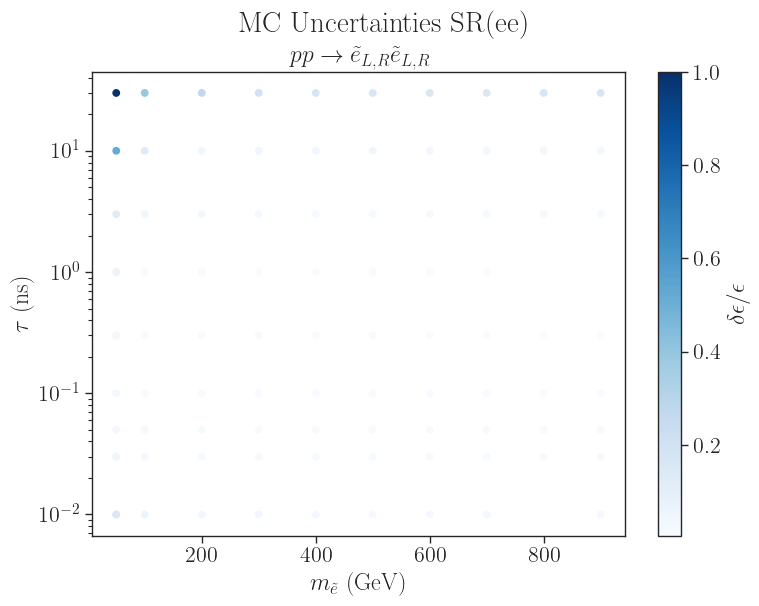

In [3]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

title = r'$p p \to \tilde{e}_{L,R} \tilde{e}_{L,R}$'
df = dfRecast
x = df['mLLP']
y = df['tau0_ns']
tit_append = ''
z = df['AccEffCuts_ee_err']/df['AccEffCuts_ee']

im = ax.scatter(x,y,c=z,cmap='Blues')
ax.set_yscale('log')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_xlabel(r'$m_{\tilde{e}}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$\delta \epsilon / \epsilon$')

ax.set_title(title)

plt.tight_layout()
plt.suptitle('MC Uncertainties SR(ee)', y=1.02)
plt.show()

## Compare with ATLAS results

In [4]:
atlasEff =  pd.read_csv('../ATLAS_data/HEPData-ins1831504-v2-csv/Selectronefficiency.csv',comment='#')
# The data file contains the centers of the bins, but the correct lifetime and mass values are the lower edges,
# so we need to shift them
atlasEff['tau0_ns'] = (10**(atlasEff["Lifetime [log10(ns)]"]-0.5)).apply(lambda x: float(f'{x:.2e}'))
atlasEff['mLLP'] = atlasEff['Mass [GeV]']-25.0
atlasEff.drop(columns=['Lifetime [log10(ns)]','Mass [GeV]'], inplace=True)
atlasAcc =  pd.read_csv('../ATLAS_data/HEPData-ins1831504-v2-csv/Selectronacceptance.csv',comment='#')
atlasAcc['tau0_ns'] = (10**(atlasAcc["Lifetime [log10(ns)]"]-0.5)).apply(lambda x: float(f'{x:.2e}'))
atlasAcc['mLLP'] = atlasAcc['Mass [GeV]']-25.0
atlasAcc.drop(columns=['Lifetime [log10(ns)]','Mass [GeV]'], inplace=True)
atlas_ee = atlasEff.merge(atlasAcc, on=['tau0_ns','mLLP'], how='inner')
atlas_ee['AccEff_Atlas_ee'] = atlas_ee['Efficiency'] * atlas_ee['Acceptance']
atlas_ee.rename(columns={'Mass [GeV]': 'mLLP'}, inplace=True)

dfRecastAtlas = dfRecast.merge(atlas_ee, on=['mLLP', 'tau0_ns'], how='inner')

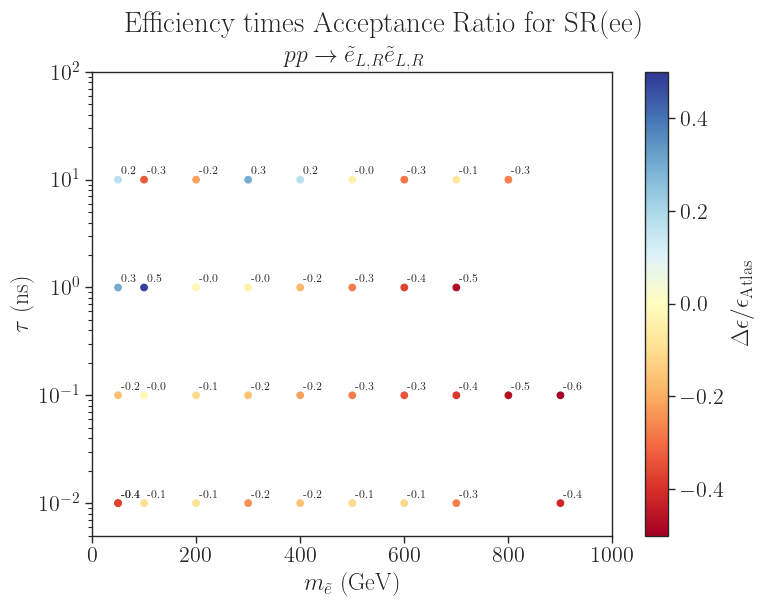

In [5]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

title = r'$p p \to \tilde{e}_{L,R} \tilde{e}_{L,R}$'
df = dfRecastAtlas
x = df['mLLP']
y = df['tau0_ns']
tit_append = ''
z = (df['AccEffCuts_ee']-df['AccEff_Atlas_ee'])/df['AccEff_Atlas_ee']
tit_append = ' (from cuts)'

# im = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
im = ax.scatter(x,y,c=z,cmap=cm,vmin=-0.5,vmax=0.5)

for xi, yi, zi in zip(x, y, z):
    ax.annotate(f'{zi:.1f}', (xi, yi), textcoords='offset points', xytext=(2, 4), fontsize=8, rotation=0)

ax.set_yscale('log')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_xlabel(r'$m_{\tilde{e}}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$\Delta \epsilon / \epsilon_{\rm Atlas}$')

ax.set_title(title)
ax.set_xlim(0.,1000.)
ax.set_ylim(5e-3,1e2)


plt.tight_layout()
plt.suptitle('Efficiency times Acceptance Ratio for SR(ee)', y=1.02)
plt.show()

## Plot Exclusion Curve

### Load official (NLO) cross-sections

In [6]:

csv_path = './slepLR_xsecs.csv'
with open(csv_path, 'r') as f:
    lines = [l for l in f.readlines() if l.strip() and not l.startswith('#')]

data = np.genfromtxt(lines, delimiter=",", names=True, dtype=float)
mass = np.atleast_1d(np.asarray(data['mass'], dtype=float))
xsec = np.atleast_1d(np.asarray(data['xsec'], dtype=float))
order = np.argsort(mass)
mass = mass[order]
xsec = xsec[order]

nloXsecF = make_interp_spline(mass, xsec,k=2)
dfRecast['xsecNLO_fb'] = nloXsecF(dfRecast['mLLP'])*1e3
dfRecast['kFactor'] = dfRecast['xsecNLO_fb']/(dfRecast['Cross-Section (pb)']*1e3)


### Compute combined upper limit (if needed)

In [7]:
if 'muUL_observed' not in dfRecast.columns:
    lumi = 139.0
    dfRecast['SRee_cuts'] = dfRecast['AccEffCuts_ee']*dfRecast['xsecNLO_fb']*lumi
    dfRecast['SRem_cuts'] = dfRecast['AccEffCuts_em']*dfRecast['xsecNLO_fb']*lumi
    dfRecast['SRmm_cuts'] = dfRecast['AccEffCuts_mm']*dfRecast['xsecNLO_fb']*lumi
    dfRecast['muUL_observed'] = dfRecast.apply(compute_poi_ul,bg_json_file=Path('../ATLAS_data/likelihood/Comb_bkgonly.json'), axis=1)

### Get ATLAS official exclusion curve for selectron pair production

In [8]:
atlas_curve = np.genfromtxt('../ATLAS_data/HEPData-ins1831504-v2-csv/Observedselectronlimits.csv',
                            delimiter=',',comments='#')
atlas_curve = atlas_curve[~np.isnan(atlas_curve[:,0])]

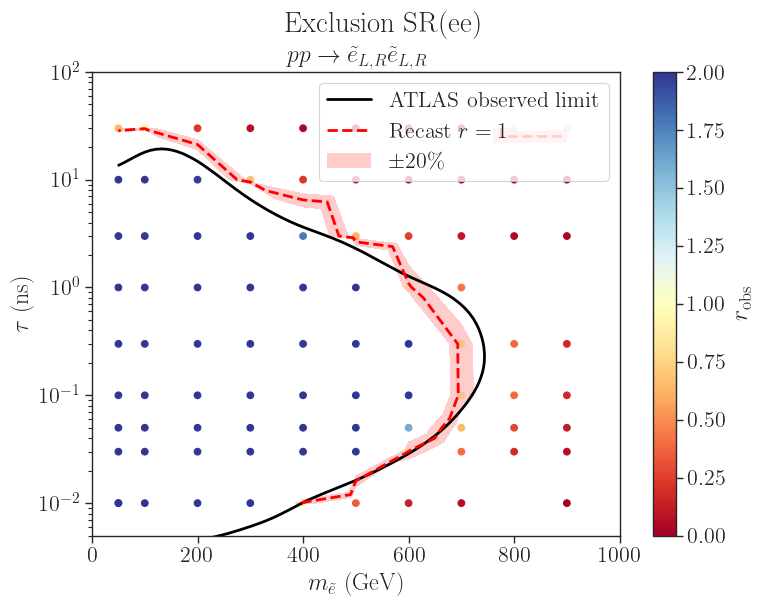

In [9]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

title = r'$p p \to \tilde{e}_{L,R} \tilde{e}_{L,R}$'
x = dfRecast['mLLP']
y = dfRecast['tau0_ns']
sigmaEffUL_ee = 0.02 # fb From https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/SUSY-2018-14/tabaux_02.png
r_best = dfRecast['AccEffCuts_ee']*dfRecast['xsecNLO_fb']/sigmaEffUL_ee
r = dfRecast['kFactor']/dfRecast['muUL_observed']

# im = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
im = ax.scatter(x,y,c=r,cmap=cm,vmin=0,vmax=2)

# for xi, yi, zi in zip(x, y, r):
    # if zi > 2.0 or zi < 0.5:
        # continue
    # ax.annotate(f'{zi:.1f}', (xi, yi), textcoords='offset points', xytext=(2, 4), fontsize=8, rotation=0)

# Filled 20% band around exclusion threshold: 0.8 <= r <= 1.2
band_r = ax.tricontourf(
    x.to_numpy(),
    y.to_numpy(),
    r.to_numpy(),
    levels=[0.8, 1.2],
    colors=['red'],
    alpha=0.2,
    zorder=2
)

# Recast observed-like contour from r = 1
cont_r1 = ax.tricontour(
    x.to_numpy(),
    y.to_numpy(),
    r.to_numpy(),
    levels=[1.0],
    colors='red',
    linewidths=2.0,
    linestyles='--',
    zorder=3
    )

atlas_line, = ax.plot(atlas_curve[:,0], atlas_curve[:,1], label='ATLAS observed limit',linewidth=2,c='black')

ax.set_yscale('log')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_xlabel(r'$m_{\tilde{e}}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$r_{\rm obs}$')

ax.set_title(title)
ax.set_xlim(0.,1000.)
ax.set_ylim(5e-3,1e2)

# Use a proxy artist so the r=1 contour appears with a dashed line in the legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
recast_proxy = Line2D([0], [0], color='red', linestyle='--', linewidth=2.0, label=r'Recast $r=1$')
band_proxy = Patch(facecolor='red', alpha=0.2, edgecolor='none', label=r'$\pm 20$\%')
ax.legend(handles=[atlas_line, recast_proxy, band_proxy])

plt.tight_layout()
plt.suptitle('Exclusion SR(ee)', y=1.02)
plt.show()